b'(r) = -r_0**2/r**2
Flare-out condition (b'(r) < 1): True
b'(10 r0) = -1.00e-02 < 1
1 - b(r)/r = 1 - r_0**2/r**2
No horizons condition (1 - b/r > 0): 1 - r_0**2/r**2 > 0
1 - b/r at r = 10 r0 = 9.90e-01 > 0
Redshift function g_tt = -1 (constant, no tidal issues)
ρ = -r_0**2/(8*pi*G_4*r**4)
p_r = -r_0**2/(8*pi*G_4*r**4)
ρ + p_r = -r_0**2/(4*pi*G_4*r**4)
NEC violation (ρ + p_r < 0): r_0**2/(4*pi*G_4*r**4) > 0
ρ(r0) = -2.28e+78 kg/m³
p_r(r0) = -2.28e+78 kg/m³
ρ + p_r at r0 = -4.57e+78 < 0


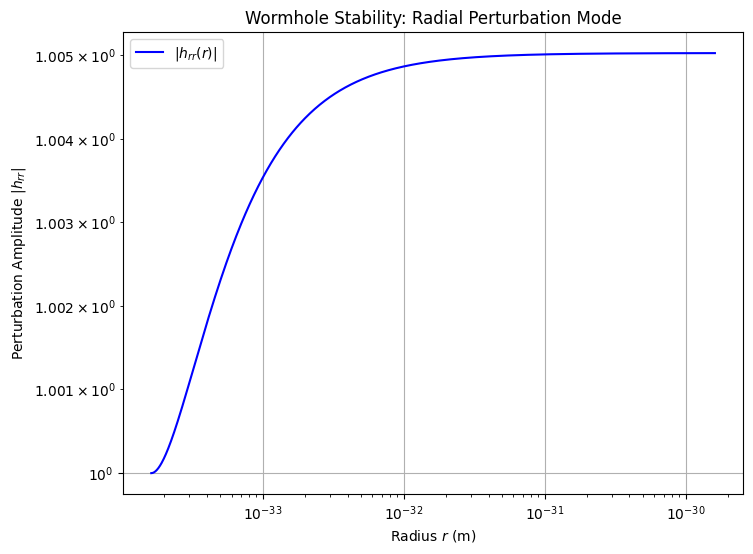

h_rr at r = 1.62e-30: 1.01e+00


In [4]:
# =====================================================
# Morris-Thorne Wormhole Conditions and Stability Analysis
# =====================================================
# This notebook verifies the Morris-Thorne (MT) conditions for a
# traversable wormhole in the Cosmic Wormhole Dynamics (CWD) model
# and analyzes its stability via linear perturbations.

import sympy as sp
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os

# --------------------------------------
# Constants
# --------------------------------------
r0 = 1.616e-35  # Throat radius (m)
G = 6.6743e-11  # Gravitational constant (SI)

# Sympy symbols
r = sp.Symbol('r', positive=True)
r_0 = sp.Symbol('r_0', positive=True)
G_4 = sp.Symbol('G_4')

# =====================================================
# C.4 Morris-Thorne Traversability Conditions
# =====================================================

# Shape function and derivative
b = r_0**2 / r
b_prime = sp.diff(b, r)

print("b'(r) =", b_prime)  # -r_0^2 / r^2
print("Flare-out condition (b'(r) < 1):", sp.simplify(b_prime < 1))

# Numerical check
b_prime_num = -r0**2 / (r0 * 10)**2
print(f"b'(10 r0) = {b_prime_num:.2e} < 1")

# No horizons
no_horizon = 1 - b/r
print("1 - b(r)/r =", no_horizon)
print("No horizons condition (1 - b/r > 0):", sp.simplify(no_horizon > 0))

no_horizon_num = 1 - r0**2 / (r0 * 10)**2
print(f"1 - b/r at r = 10 r0 = {no_horizon_num:.2e} > 0")

# Finite tidal forces
print("Redshift function g_tt = -1 (constant, no tidal issues)")

# NEC violation
rho = b_prime / (8 * sp.pi * G_4 * r**2)
p_r = - b / (8 * sp.pi * G_4 * r**3)
nec = rho + p_r
print("ρ =", rho)
print("p_r =", p_r)
print("ρ + p_r =", nec)
print("NEC violation (ρ + p_r < 0):", sp.simplify(nec < 0))

# Numerical check at throat
rho_throat = -1 / (8 * sp.pi * G * r0**2)
p_r_throat = -1 / (8 * sp.pi * G * r0**3) * (r0**2 / r0)
nec_throat = rho_throat + p_r_throat
print(f"ρ(r0) = {float(rho_throat):.2e} kg/m³")
print(f"p_r(r0) = {float(p_r_throat):.2e} kg/m³")
print(f"ρ + p_r at r0 = {float(nec_throat):.2e} < 0")

# =====================================================
# C.5 Linear Stability Analysis
# =====================================================

def ode_system(r, y):
    h, h_prime = y
    coeff = 2 * (r**2 - r0**2) / (r * (r**2 - r0**2))
    potential = -r0**2 / (r**2 * (r**2 - r0**2))
    return np.vstack([h_prime, -coeff * h_prime - potential * h])

def bc(ya, yb):
    return np.array([ya[0] - 1, ya[1]])  # h(r0) = 1, h'(r0) = 0

# Initial mesh for solver
r_range = np.logspace(np.log10(r0 * 10), np.log10(r0 * 1e5), 200)
y_init = np.zeros((2, r_range.size))

# Solve BVP
sol = solve_bvp(ode_system, bc, r_range, y_init, tol=1e-6)

# Extract solution
h_rr = sol.y[0]
r_mesh = sol.x  # Use solver's mesh points

# Ensure output directory exists
os.makedirs("figures/appendix_c", exist_ok=True)

# Plot stability modes
plt.figure(figsize=(8, 6))
plt.loglog(r_mesh, np.abs(h_rr), label=r'$|h_{rr}(r)|$', color='blue')
plt.xlabel("Radius $r$ (m)")
plt.ylabel("Perturbation Amplitude $|h_{rr}|$")
plt.title("Wormhole Stability: Radial Perturbation Mode")
plt.grid(True)
plt.legend()
plt.savefig("figures/appendix_c/stability_modes.png")
plt.show()

print(f"h_rr at r = {r_mesh[-1]:.2e}: {h_rr[-1]:.2e}")